In [1]:
import pandas as pd
df = pd.read_csv('rolling_results_all_feature_2year_1year_label2.csv')
df


,Unnamed: 0,Training_years,Testing year,Best Params,PR-AUC,Best threshold,F1-score_test,Precision_test,Recall_test,F1 Gap (Train-Test),Train_size,Test_size
0,0,2013_2014,[2015],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.2758,0.560431,0.377123,0.423808,0.339703,-0.017994,1041192,530021
1,1,2014_2015,[2016],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.3196,0.815204,0.409863,0.511768,0.341802,0.277816,1049991,524543
2,2,2015_2016,[2017],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.1622,0.785037,0.295621,0.396681,0.235599,0.292188,1054564,468913
3,3,2016_2017,[2018],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.5534,0.642628,0.647688,0.685106,0.614146,0.006762,993456,491374
4,4,2017_2018,[2019],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.5004,0.725172,0.490492,0.502351,0.479180,0.142075,960287,497246
5,5,2018_2019,[2020],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.5749,0.807142,0.625055,0.701444,0.563670,0.232144,988620,524057
6,6,2019_2020,[2021],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.4094,0.868109,0.460177,0.881618,0.311345,0.214092,1021303,509384
7,7,2020_2021,[2022],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.1999,0.672823,0.346624,0.477113,0.272182,0.293969,1033441,531485
8,8,2021_2022,[2023],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.0517,0.733031,0.149556,0.159894,0.140473,0.477049,1040869,512423
9,9,2022_2023,[2024],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.0924,0.743523,0.171484,0.109887,0.390222,0.281184,1043908,485872


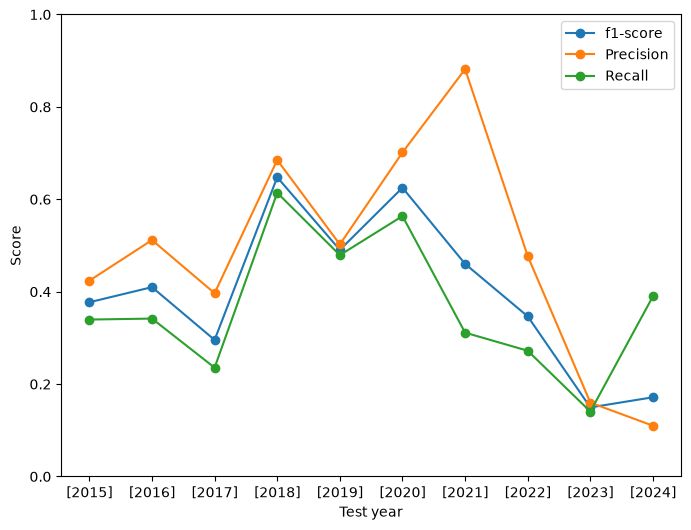

In [2]:
import matplotlib.pyplot as plt

plt.subplots(figsize=(8,6))
plt.plot(df['Testing year'], df['F1-score_test'], marker='o', label='f1-score')
plt.plot(df['Testing year'], df['Precision_test'], marker='o', label='Precision')
plt.plot(df['Testing year'], df['Recall_test'], marker='o', label='Recall')
plt.xlabel('Test year')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend()

plt.show()

In [ ]:
df_feature = pd.read_csv('df_imp_0730_label2.csv', index_col=0)
df_feature.index.name = 'Feature'
# year is the first training year
# example 2013, mean training on 2013-2014, testing on 2014(2 years, 1year)
df_feature

,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
Feature,,,,,,,,,,
co2_dry,0.061222,0.032721,0.024133,0.029691,0.011575,0.021373,0.015585,0.031495,0.020766,0.013225
co2_wet,0.031506,0.016436,0.017635,0.018081,0.014073,0.014013,0.011209,0.012456,0.007654,0.015226
co2_target_error,0.004317,0.001170,0.009434,0.058336,0.067989,0.047427,0.033872,0.054484,0.042394,0.026420
co2_Cdrift,0.030565,0.007055,0.007884,0.020436,0.011051,0.007492,0.013302,0.038092,0.014358,0.012143
co2_Nfiltered,0.001495,0.001696,0.010445,0.009930,0.004901,0.004256,0.005505,0.006342,0.007267,0.006928
...,...,...,...,...,...,...,...,...,...,...
co2_target_error_5min_zcore_res_gen,0.000236,0.000323,0.000771,0.000711,0.001521,0.001584,0.001157,0.000887,0.001033,0.000986
co2_target_error_per_rank_60s,0.000155,0.000000,0.000071,0.000000,0.000587,0.000000,0.000000,0.000000,0.000000,0.000000
co2_target_error_per_rank_5min,0.000491,0.001182,0.002064,0.002441,0.001007,0.002379,0.001638,0.002545,0.002336,0.001380


In [4]:

rank_df  = df_feature.rank(ascending=False, axis=0)

top10_counts =  (rank_df <=10).sum(axis=1).sort_values(ascending=False)

print("Top 10:",top10_counts)

Top 10: Feature
outlet_valve_cavity_press_ratio        10
h2o_log                                10
co2_wet_co2_dry_diff_cross              9
outlet_valve                            9
h2o_co2_dry_multi                       9
                                       ..
co2_target_error_5min_zcore_res_gen     0
co2_target_error_per_rank_60s           0
co2_target_error_per_rank_5min          0
co2_Cdrift_per_rank_60s                 0
co2_Cdrift_per_rank_5min                0
Length: 68, dtype: int64


In [6]:
import seaborn as sns

In [10]:
df = pd.read_csv('../data/processed/mhd_ch4_cnan_v1.csv')
df.to_parquet('../data/processed/mhd_ch4_cnan_v1.parquet')

Text(0.5, 1.0, 'Heatmap of Training Feature Importances Across Rolling Windows')

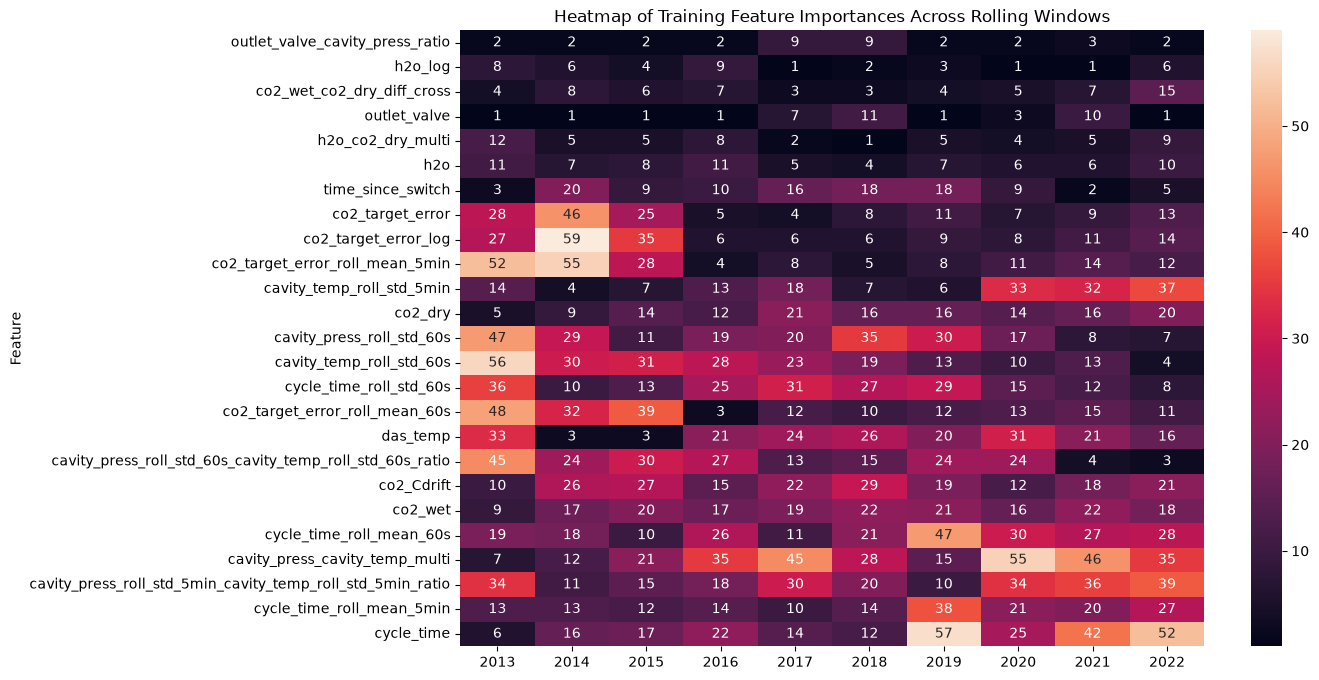

In [7]:
plot_features = top10_counts[top10_counts>0].index
plt.figure(figsize=(12,8))
sns.heatmap(
    rank_df.loc[plot_features],
    annot=True,
)
plt.title('Heatmap of Training Feature Importances Across Rolling Windows')

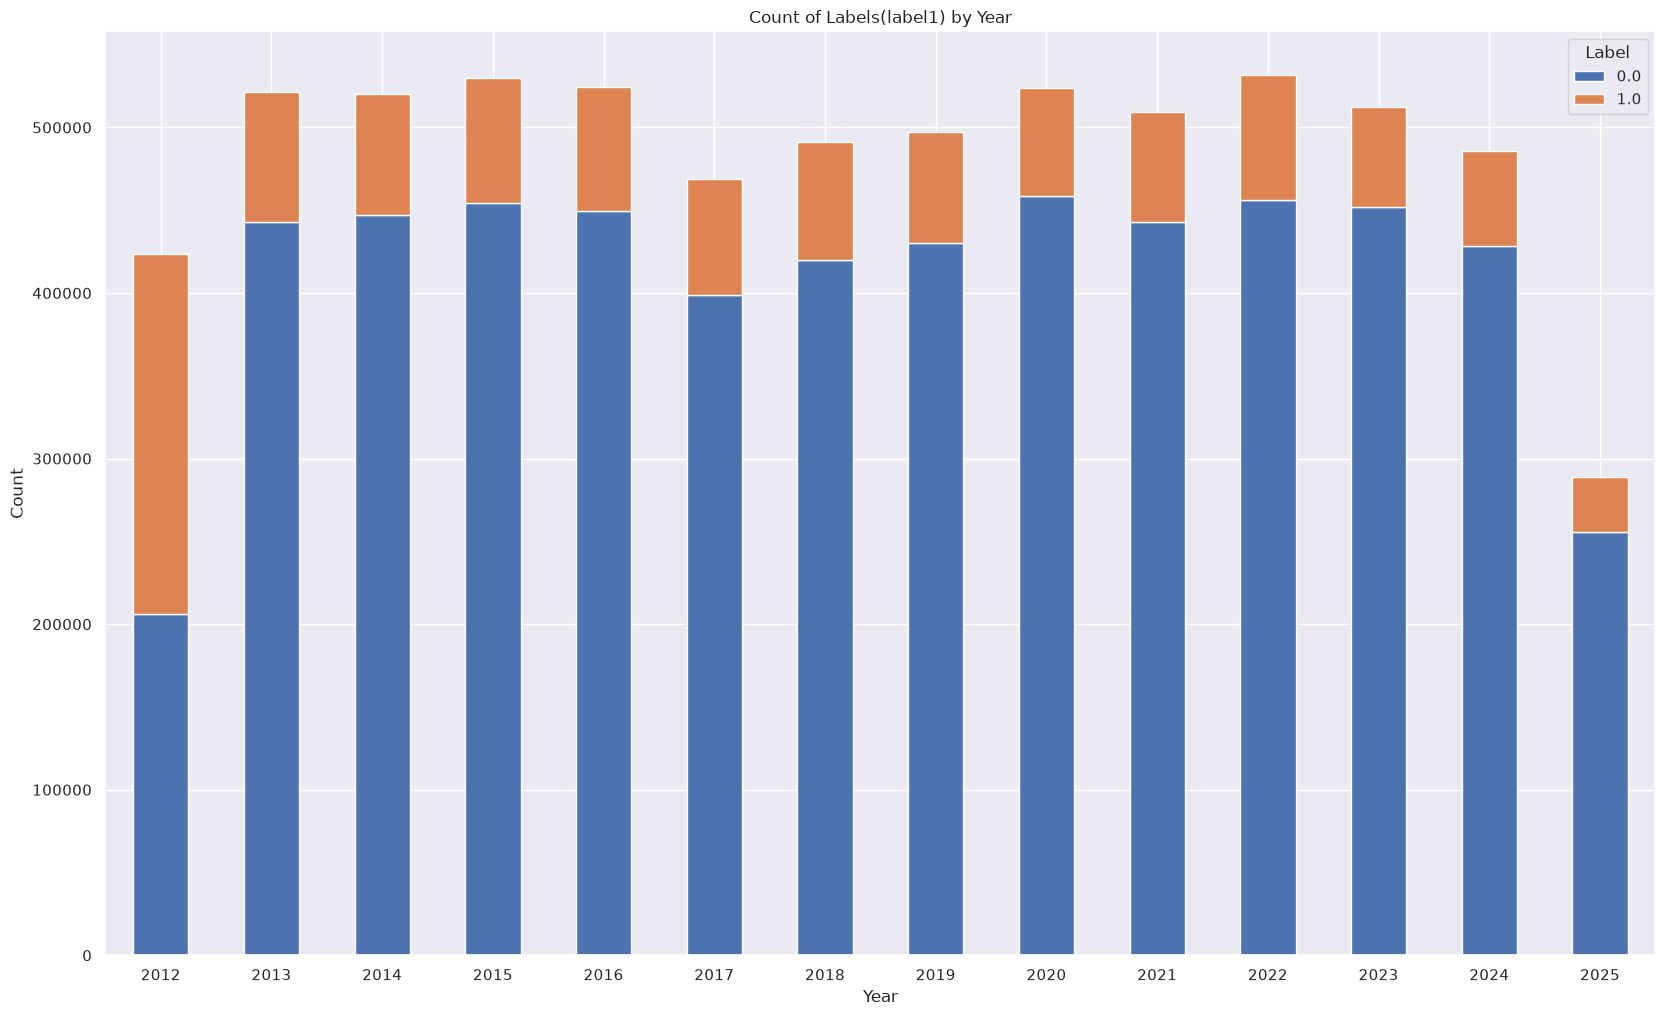

======================================

In [39]:
df = pd.read_csv('final_paper_table_2_1.csv')
df = df[:-1]
df

,Unnamed: 0,Training_years,Testing year,Best Params,PR-AUC,Best threshold,F1-score_test,Precision_test,Recall_test,F1 Gap (Train-Test),Train_size,Test_size,Training_Year,Test Year
0,0,2012_2013,[2014],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.9210,0.539047,0.879316,0.901197,0.858473,0.161330,944555.0,519970.0,NaN,NaN
1,1,2013_2014,[2015],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.9055,0.721981,0.906469,0.982150,0.841618,0.540715,1041192.0,530021.0,NaN,NaN
2,2,2014_2015,[2016],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.9416,0.760674,0.905273,0.976071,0.844051,0.067889,1049991.0,524543.0,NaN,NaN
3,3,2015_2016,[2017],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.8960,0.734186,0.844927,0.967242,0.750075,0.226587,1054564.0,468913.0,NaN,NaN
4,4,2016_2017,[2018],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.9788,0.522528,0.932702,0.936309,0.929123,-0.018920,993456.0,491374.0,NaN,NaN
5,5,2017_2018,[2019],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.9669,0.702560,0.947730,0.968568,0.927770,-0.028149,960287.0,497246.0,NaN,NaN
6,6,2018_2019,[2020],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.9822,0.649835,0.956501,0.976626,0.937188,-0.011156,988620.0,524057.0,NaN,NaN
7,7,2019_2020,[2021],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.9685,0.628677,0.942429,0.978268,0.909124,0.008894,1021303.0,509384.0,NaN,NaN
8,8,2020_2021,[2022],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.8478,0.784301,0.760691,0.700611,0.832042,0.435916,1033441.0,531485.0,NaN,NaN
9,9,2021_2022,[2023],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.9032,0.711020,0.869680,0.869320,0.870041,0.170110,1040869.0,512423.0,NaN,NaN


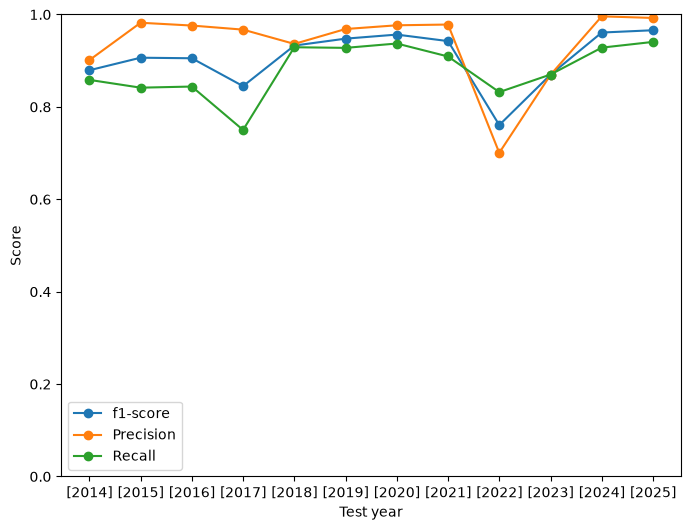

In [40]:
import matplotlib.pyplot as plt

plt.subplots(figsize=(8,6))
plt.plot(df['Testing year'], df['F1-score_test'], marker='o', label='f1-score')
plt.plot(df['Testing year'], df['Precision_test'], marker='o', label='Precision')
plt.plot(df['Testing year'], df['Recall_test'], marker='o', label='Recall')
plt.xlabel('Test year')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend()